# Digital Wallet Transactions — Analysis



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
df = pd.read_csv("../data/digital_wallet_transactions.csv")

In [3]:
df.head()

,idx,transaction_id,user_id,transaction_date,product_category,product_name,merchant_name,product_amount,transaction_fee,cashback,loyalty_points,payment_method,transaction_status,merchant_id,device_type,location
0,1,4dac3ea3-6492-46ec-80b8-dc45c3ad0b14,USER_05159,2023-08-19 03:32,Rent Payment,2BHK Flat Deposit,Airbnb,"1,525.39",36.69,19.19,186,Debit Card,Successful,MERCH_0083,iOS,Urban
1,2,a903ed9f-eb84-47e7-b8aa-fd1786c919cf,USER_07204,2023-08-19 04:37,Gas Bill,Commercial Gas Connection,Adani Gas,"1,495.40",28.19,89.99,182,UPI,Successful,MERCH_0163,iOS,Urban
2,3,2a393013-733c-4add-9f09-bed1eeb33676,USER_00903,2023-08-19 05:52,Bus Ticket,Semi-Sleeper,MakeMyTrip Bus,"1,267.71",11.36,95.70,994,UPI,Successful,MERCH_0320,iOS,Urban
3,4,9a07ad19-4673-4794-9cd2-9b139f39c715,USER_01769,2023-08-19 06:35,Internet Bill,4G Unlimited Plan,Airtel Broadband,"9,202.63",6.41,82.24,409,Debit Card,Successful,MERCH_0194,Android,Urban
4,5,76418260-c985-4011-979d-0914604d0d68,USER_03544,2023-08-19 06:36,Loan Repayment,Home Loan EMI,Axis Bank,"3,100.58",41.15,40.47,837,Debit Card,Successful,MERCH_0504,Android,Urban


In [4]:
df.shape

(5000, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   idx                 5000 non-null   int64  
 1   transaction_id      5000 non-null   str    
 2   user_id             5000 non-null   str    
 3   transaction_date    5000 non-null   str    
 4   product_category    5000 non-null   str    
 5   product_name        5000 non-null   str    
 6   merchant_name       5000 non-null   str    
 7   product_amount      5000 non-null   float64
 8   transaction_fee     5000 non-null   float64
 9   cashback            5000 non-null   float64
 10  loyalty_points      5000 non-null   int64  
 11  payment_method      5000 non-null   str    
 12  transaction_status  5000 non-null   str    
 13  merchant_id         5000 non-null   str    
 14  device_type         5000 non-null   str    
 15  location            5000 non-null   str    
dtypes: float64(3), in

In [6]:
df.describe()

,idx,product_amount,transaction_fee,cashback,loyalty_points
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"2,500.50","4,957.50",25.19,50.66,498.79
std,"1,443.52","2,885.03",14.54,28.52,288.96
min,1.00,10.09,0.01,0.00,0.00
25%,"1,250.75","2,453.98",12.66,26.50,246.00
50%,"2,500.50","4,943.68",25.07,51.39,504.00
75%,"3,750.25","7,444.82",37.95,75.07,749.00
max,"5,000.00","9,996.95",49.99,100.00,999.00


## Data Quality Checks

The original notebook checked for duplicate rows but never removed them, and never checked
for missing values at all. Both are added here, with the row count tracked before/after so
the impact is visible.

In [7]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
Series([], dtype: int64)

Duplicate rows: 0


In [9]:
df['transaction_date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [10]:
df['transaction_date'] = df['transaction_date'].astype('datetime64[ns]')

In [11]:
df['transaction_date'].dtype

dtype('<M8[ns]')

## Outlier Inspection

Boxplots flag whether any numeric column has extreme values worth a closer look. These are
inspection-only: nothing is dropped or capped automatically, since legitimate transactions
(e.g. a large rent deposit) can look like outliers on a boxplot without being a data error.
If a run shows outliers far outside the plausible range for that field, decide case-by-case
whether to cap, investigate, or leave them.

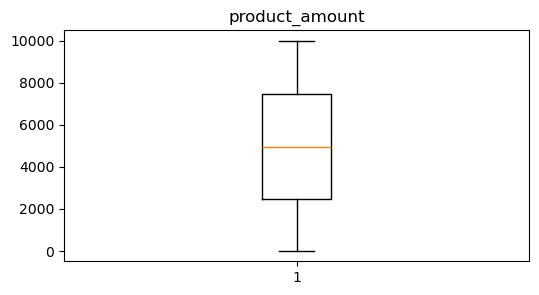

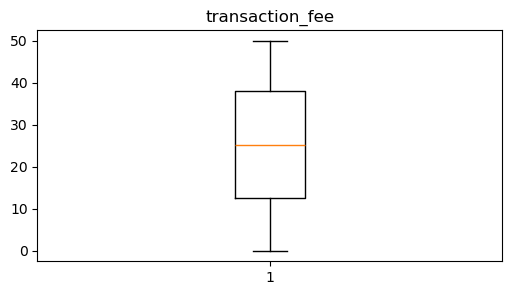

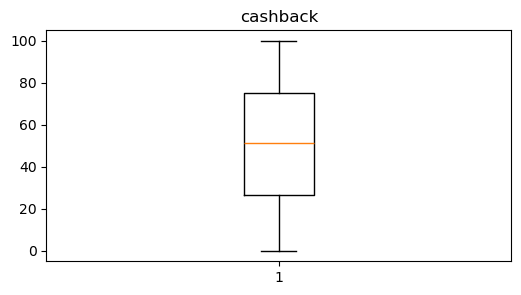

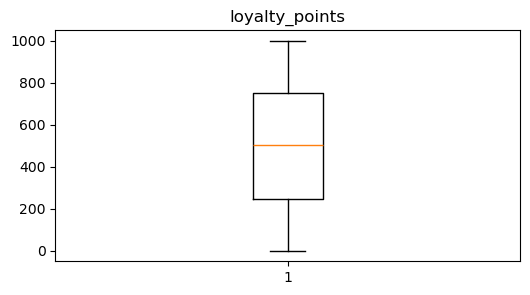

In [12]:
numerical_columns = [
    'product_amount',
    'transaction_fee',
    'cashback',
    'loyalty_points'
]

for col in numerical_columns:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

## FEATURE ENGINEERING

In [13]:
df['month'] = df['transaction_date'].dt.month_name()

In [14]:
df['day_name'] = df['transaction_date'].dt.day_name()

In [15]:
df['hour'] = df['transaction_date'].dt.hour

In [16]:
df['weekend'] = df['transaction_date'].dt.dayofweek >= 5

In [17]:
df['weekend'] = df['weekend'].map({
    True:'Yes',
    False:'No'
})

In [18]:
text_columns = ['payment_method', 'transaction_status', 'device_type', 'location',
                'product_category', 'product_name', 'merchant_name']

for col in text_columns:
    df[col] = df[col].str.strip().str.title()

In [19]:
df.head()

,idx,transaction_id,user_id,transaction_date,product_category,product_name,merchant_name,product_amount,transaction_fee,cashback,loyalty_points,payment_method,transaction_status,merchant_id,device_type,location,month,day_name,hour,weekend
0,1,4dac3ea3-6492-46ec-80b8-dc45c3ad0b14,USER_05159,2023-08-19 03:32:00,Rent Payment,2Bhk Flat Deposit,Airbnb,"1,525.39",36.69,19.19,186,Debit Card,Successful,MERCH_0083,Ios,Urban,August,Saturday,3,Yes
1,2,a903ed9f-eb84-47e7-b8aa-fd1786c919cf,USER_07204,2023-08-19 04:37:00,Gas Bill,Commercial Gas Connection,Adani Gas,"1,495.40",28.19,89.99,182,Upi,Successful,MERCH_0163,Ios,Urban,August,Saturday,4,Yes
2,3,2a393013-733c-4add-9f09-bed1eeb33676,USER_00903,2023-08-19 05:52:00,Bus Ticket,Semi-Sleeper,Makemytrip Bus,"1,267.71",11.36,95.70,994,Upi,Successful,MERCH_0320,Ios,Urban,August,Saturday,5,Yes
3,4,9a07ad19-4673-4794-9cd2-9b139f39c715,USER_01769,2023-08-19 06:35:00,Internet Bill,4G Unlimited Plan,Airtel Broadband,"9,202.63",6.41,82.24,409,Debit Card,Successful,MERCH_0194,Android,Urban,August,Saturday,6,Yes
4,5,76418260-c985-4011-979d-0914604d0d68,USER_03544,2023-08-19 06:36:00,Loan Repayment,Home Loan Emi,Axis Bank,"3,100.58",41.15,40.47,837,Debit Card,Successful,MERCH_0504,Android,Urban,August,Saturday,6,Yes


In [20]:
df.to_csv("../data/cleaned_transactions.csv", index=False)

## EDA

Total transaction amount

In [21]:
total_amount = df['product_amount'].sum()

print(f"{total_amount:,.2f}")

24,787,513.61


Total transaction fees

In [22]:
total_fees = df['transaction_fee'].sum()

print(f"{total_fees:,.2f}")

125,944.37


Total cashback

In [23]:
total_cashback = df['cashback'].sum()

print(f"{total_cashback:,.2f}")

253,293.91


Net earnings

**Note:** this is fee revenue minus cashback paid out, i.e. the wallet provider's net
position on these two line items — it is *not* the platform's overall profit, since it
ignores other revenue (merchant commissions, subscriptions, interest float, etc.) and other
costs (infrastructure, support, fraud losses). On this dataset the result is negative,
meaning cashback paid out exceeds fee income; that's worth flagging rather than just
printing, since on its own it would suggest the loyalty/cashback program isn't
self-funding from fees alone — by design or not.

In [24]:
net_earnings = total_fees - total_cashback

print(f"{net_earnings:,.2f}")

if net_earnings < 0:
    print("Note: cashback paid out exceeds fee revenue on this slice of data.")

-127,349.54
Note: cashback paid out exceeds fee revenue on this slice of data.


Transaction Performance
Success vs Failed vs Pending percentages

In [25]:
status_percentage = (
    df['transaction_status']
    .value_counts(normalize=True)
    * 100
)

print(status_percentage)

transaction_status
Successful   95.10
Failed        2.92
Pending       1.98
Name: proportion, dtype: float64


Peak hours

In [26]:
peak_hours = (
    df['hour']
    .value_counts()
    .sort_index()
)

print(peak_hours)

hour
0     214
1     184
2     209
3     203
4     204
5     205
6     208
7     219
8     201
9     209
10    226
11    220
12    199
13    191
14    227
15    200
16    191
17    210
18    194
19    225
20    207
21    217
22    217
23    220
Name: count, dtype: int64


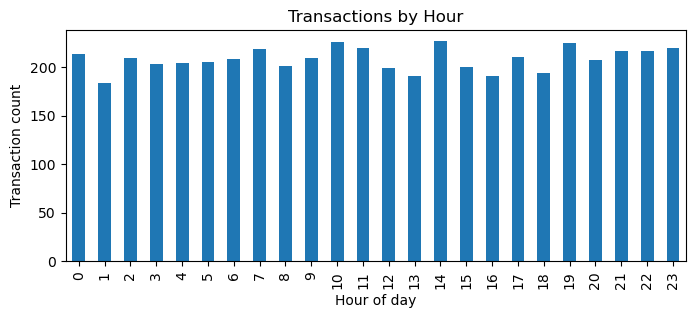

In [ ]:
peak_hours.plot(kind='bar', figsize=(8,3), title='Transactions by Hour')
plt.xlabel('Hour of day')
plt.ylabel('Transaction count')
plt.show()

Most active days

In [28]:
active_days = (
    df['day_name']
    .value_counts()
)

print(active_days)

day_name
Wednesday    753
Sunday       742
Saturday     720
Thursday     710
Tuesday      697
Monday       693
Friday       685
Name: count, dtype: int64


Customer Behavior
Most used payment methods

In [29]:
payment_methods = (
    df['payment_method']
    .value_counts()
)

print(payment_methods)

payment_method
Bank Transfer     1045
Debit Card        1022
Upi                999
Credit Card        992
Wallet Balance     942
Name: count, dtype: int64


Most used devices

In [30]:
devices = (
    df['device_type']
    .value_counts()
)

print(devices)

device_type
Android    2995
Ios        1526
Web         479
Name: count, dtype: int64


Most active locations

In [31]:
locations = (
    df['location']
    .value_counts()
)

print(locations)

location
Urban       3485
Suburban    1017
Rural        498
Name: count, dtype: int64


Product Insights
Best product categories

In [32]:
categories = (
    df.groupby('product_category')['product_amount']
    .sum()
    .sort_values(ascending=False)
)

print(categories)

product_category
Streaming Service   1,462,461.66
Water Bill          1,400,668.85
Gas Bill            1,361,519.80
Education Fee       1,349,321.77
Movie Ticket        1,337,399.89
Hotel Booking       1,319,603.90
Food Delivery       1,317,106.21
Taxi Fare           1,306,566.24
Rent Payment        1,258,263.69
Internet Bill       1,247,178.07
Electricity Bill    1,245,972.74
Loan Repayment      1,210,681.76
Online Shopping     1,207,396.13
Mobile Recharge     1,196,334.68
Gaming Credits      1,136,665.44
Grocery Shopping    1,134,972.71
Flight Booking      1,124,283.05
Bus Ticket          1,115,711.58
Insurance Premium   1,032,608.99
Gift Card           1,022,796.45
Name: product_amount, dtype: float64


Best products

In [33]:
products = (
    df.groupby('product_name')['product_amount']
    .sum()
    .sort_values(ascending=False)
)

print(products.head(10))

product_name
Basic Plan                  379,539.37
Python Programming Course   369,045.91
Commercial Property         333,964.54
Industrial Gas Supply       331,754.57
Share Ride                  315,885.86
City Ride                   313,225.05
Legendary Weapon            312,569.63
Standard Plan               309,157.33
Vegetable Biryani           302,472.94
Commercial Space Rent       301,142.10
Name: product_amount, dtype: float64


Top merchants

In [34]:
merchants = (
    df.groupby('merchant_name')['product_amount']
    .sum()
    .sort_values(ascending=False)
)

print(merchants.head(10))

merchant_name
Airbnb                   550,248.40
Flipkart                 458,472.89
Makemytrip               438,496.77
Bangalore Water Supply   337,482.55
Netflix                  335,355.47
Coursera                 327,903.71
Cinepolis                321,819.33
Uber Eats                315,692.09
Carnival Cinemas         314,782.60
Hotstar                  314,131.11
Name: product_amount, dtype: float64


Loyalty Program Analysis
Loyalty points by category

In [35]:
loyalty = (
    df.groupby('product_category')['loyalty_points']
    .sum()
    .sort_values(ascending=False)
)

print(loyalty)

product_category
Streaming Service    154187
Hotel Booking        138772
Water Bill           137217
Education Fee        135073
Taxi Fare            131527
Food Delivery        130077
Movie Ticket         127701
Electricity Bill     127312
Rent Payment         126527
Loan Repayment       125202
Online Shopping      120849
Grocery Shopping     119898
Gas Bill             119866
Mobile Recharge      119676
Gaming Credits       118792
Insurance Premium    116995
Bus Ticket           115844
Internet Bill        111868
Flight Booking       111801
Gift Card            104768
Name: loyalty_points, dtype: int64


Does cashback increase transaction amount?

**Note on interpretation:** this is a Pearson correlation between two columns in the same
row, i.e. "do transactions with higher cashback tend to have a higher product amount,"
not a causal test of whether *giving* cashback *causes* people to spend more. A value near
0 means little linear association either way — it doesn't on its own say the cashback
program has no effect, since this dataset doesn't have a control group of identical
transactions without cashback to compare against.

In [36]:
correlation = (
    df['cashback']
    .corr(df['product_amount'])
)

print(correlation)

0.005515128285459527


## Payment Method vs Transaction Success Rate

The dataset description specifically calls out "investigating the relationship between
payment methods and transaction success rates" as an intended use case. The original
notebook computes each separately but never crosses them — added here.

In [37]:
success_by_method = (
    df.groupby('payment_method')['transaction_status']
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .fillna(0)
    .round(2)
)

print(success_by_method)

transaction_status  Failed  Pending  Successful
payment_method                                 
Bank Transfer         2.78     1.72       95.50
Credit Card           3.53     2.42       94.05
Debit Card            2.45     0.88       96.67
Upi                   2.50     2.40       95.10
Wallet Balance        3.40     2.55       94.06


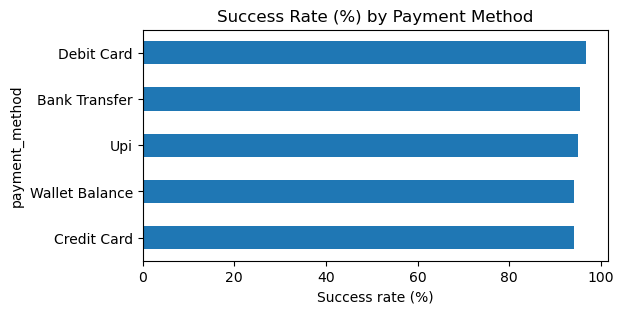

In [38]:
success_by_method['Successful'].sort_values().plot(
    kind='barh', figsize=(6,3), title='Success Rate (%) by Payment Method'
)
plt.xlabel('Success rate (%)')
plt.show()

## User Segmentation

Another explicit use case from the dataset card ("segmenting users based on their spending
behavior") that the original notebook doesn't touch — it never groups by `user_id`. Added
below: a per-user summary, then a simple spend-tier split.

In [40]:
user_summary = df.groupby('user_id').agg(
    total_spent=('product_amount', 'sum'),
    avg_transaction=('product_amount', 'mean'),
    transaction_count=('product_amount', 'count'),
    total_cashback=('cashback', 'sum'),
).sort_values('total_spent', ascending=False)

print(user_summary.head(10))

            total_spent  avg_transaction  transaction_count  total_cashback
user_id                                                                    
USER_04724    29,315.93         7,328.98                  4          267.52
USER_08946    28,799.29         7,199.82                  4          161.88
USER_05836    25,189.19         6,297.30                  4          305.68
USER_03945    25,063.95         6,265.99                  4          135.53
USER_05744    24,949.89         8,316.63                  3          182.22
USER_08775    24,700.25         8,233.42                  3          103.34
USER_08584    23,842.59         5,960.65                  4          203.29
USER_03888    23,800.76         7,933.59                  3          266.31
USER_00949    23,748.91         7,916.30                  3          224.25
USER_01223    23,524.42         5,881.10                  4          204.48


In [41]:
# Quantile-based tiers so the split adapts to whatever the real distribution looks like,
# rather than hardcoding fixed spend thresholds
user_summary['spend_tier'] = pd.qcut(
    user_summary['total_spent'],
    q=[0, 0.5, 0.8, 1.0],
    labels=['Low', 'Medium', 'High']
)

print(user_summary['spend_tier'].value_counts())

spend_tier
Low       1966
Medium    1179
High       787
Name: count, dtype: int64


In [42]:
tier_profile = (
    user_summary
    .groupby('spend_tier', observed=True)[['total_spent', 'avg_transaction', 'transaction_count', 'total_cashback']]
    .mean()
    .round(2)
)

print(tier_profile)

            total_spent  avg_transaction  transaction_count  total_cashback
spend_tier                                                                 
Low            3,063.89         2,923.59               1.07           54.67
Medium         7,588.63         6,910.31               1.18           59.78
High          12,473.84         7,136.51               1.90           95.71


## Summary

A short recap of what stood out, in plain terms — fill in the actual numbers from the
outputs above after running this notebook on the real file:

- **Success rate:** what share of transactions are `Successful` vs `Failed`/`Pending` —
  this is a base health metric for the wallet.
- **Net fee/cashback position:** whether fee income covers cashback payouts on this data
  slice (see the Net Earnings note above).
- **Peak usage:** which hour(s) and day(s) see the most transactions — useful for staffing
  support or scheduling promotions.
- **Channel mix:** which payment method, device type, and location category dominate usage.
- **Top categories/products/merchants:** where transaction value concentrates.
- **Cashback vs spend correlation:** how strong the linear relationship is, with the caveat
  above about correlation vs. causation.
- **Success rate by payment method:** whether any payment method stands out as more
  failure-prone than the others — if one does, that's a candidate for deeper investigation
  (gateway issues, user error, etc.) rather than just a number to report.
- **User segmentation:** how spend splits across the Low/Medium/High tiers — in particular
  whether the High tier is a small group driving a disproportionate share of total spend
  (common in transaction data) or more evenly spread.

This summary is a template — replace the bullets above with the actual figures once this
notebook is run against the full dataset.